In [62]:
import pandas as pd
import numpy as np
import re
import regex
import matplotlib.pyplot as plt
from english_words import get_english_words_set

In [63]:
# Load files only cols we need

df_lyrics = pd.read_csv(r"C:\Users\conno\OneDrive - Queen's University\Desktop\songs_with_attributes_and_lyrics.csv",usecols=['id','lyrics'])

df_genre = pd.read_csv(r"C:\Users\conno\OneDrive - Queen's University\Desktop\dataset.csv",usecols=['track_id','track_genre'])

In [64]:
df_lyrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955320 entries, 0 to 955319
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      955320 non-null  object
 1   lyrics  955307 non-null  object
dtypes: object(2)
memory usage: 14.6+ MB


In [65]:
df_genre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   track_id     114000 non-null  object
 1   track_genre  114000 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [66]:
# Remove any duplicate rows
df_lyrics = df_lyrics.drop_duplicates()
df_genre = df_genre.drop_duplicates()

### Remove songs with multiple

In [67]:
# remove same tracks with multiple genres
df_genre = df_genre[['track_id','track_genre']].drop_duplicates(subset="track_id",keep=False)

### Merge dataframes

In [68]:
df_joined = pd.merge(df_genre,df_lyrics,left_on="track_id",right_on="id")

In [80]:
df_joined

,track_id,track_genre,id,lyrics
0,1iJBSr7s7jYXzM8EGcbK5b,acoustic,1iJBSr7s7jYXzM8EGcbK5b,"When the world was ending, I'd hold you in my ..."
1,6lfxq3CG4xtTiEg7opyCyx,acoustic,6lfxq3CG4xtTiEg7opyCyx,Wise men say\n ♪\n Only fools rush in\n ♪\n Bu...
2,5vjLSffimiIP26QG5WcN2K,acoustic,5vjLSffimiIP26QG5WcN2K,"Loving and fighting, accusing, denying\n I can..."
3,0IktbUcnAGrvD03AWnz3Q8,acoustic,0IktbUcnAGrvD03AWnz3Q8,Do you hear me? I'm talking to you\n Across th...
4,4mzP5mHkRvGxdhdGdAH7EJ,acoustic,4mzP5mHkRvGxdhdGdAH7EJ,"Do you remember, when we were young\n You were..."
...,...,...,...,...
45588,6PM55W7WiUmHVPdUebJP55,world-music,6PM55W7WiUmHVPdUebJP55,I'll never leave You\n I've tasted Your goodne...
45589,0CE0Y6GM75cbrqao8EOAlW,world-music,0CE0Y6GM75cbrqao8EOAlW,There's a place where mercy reigns\n And never...
45590,4OkMK49i3NApR1KsAIsTf6,world-music,4OkMK49i3NApR1KsAIsTf6,"There is an endless song, echoes in my soul\n ..."
45591,2e6sXL2bYv4bSz6VTdnfLs,world-music,2e6sXL2bYv4bSz6VTdnfLs,Packing up the dreams God planted\n In the fer...


In [69]:
# calculate whether each lyric set has multiple genres
unique_counts = df_joined.groupby('lyrics')['track_genre'].transform('nunique')
# If same lyrics show up with different genres then remove

df_removed = df_joined[unique_counts == 1].copy().drop_duplicates(subset=["lyrics","track_genre"])

### Create Parent Genre and Remove irrelavent genres

In [70]:
df_parent_genre = pd.read_csv('genre_parent_mapping.csv')

df_removed = pd.merge(df_removed,df_parent_genre,left_on='track_genre',right_on='original_genre')

df_filtered_genres = df_removed[df_removed['included'] == True]

### Remove songs without enough lyrics

In [71]:
lyrics_cleaned = [regex.sub(r'[^\p{L}\s]', '', text).lower() for text in df_filtered_genres['lyrics'].to_list()]
lyrics_word_list = [word_list.split() for word_list in lyrics_cleaned]

lyrics_count = [len(item) for item in lyrics_word_list]

df_filtered_genres['lyric_count'] = lyrics_count
df_filtered_genres['song_vocab'] = [set(item) for item in lyrics_word_list]
df_filtered_genres['lyrics_cleaned'] = lyrics_cleaned

C:\Users\conno\AppData\Local\Temp\ipykernel_18092\4292525641.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_genres['lyric_count'] = lyrics_count
C:\Users\conno\AppData\Local\Temp\ipykernel_18092\4292525641.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_genres['song_vocab'] = [set(item) for item in lyrics_word_list]
C:\Users\conno\AppData\Local\Temp\ipykernel_18092\4292525641.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

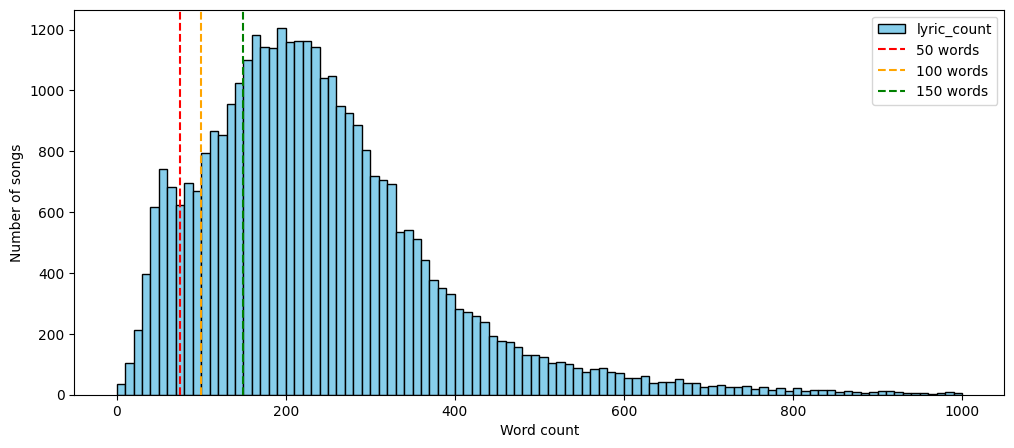

In [72]:
df_filtered_genres['lyric_count'].plot.hist(bins=100,range=(0,1000),edgecolor='black', color='skyblue',figsize=(12,5))
plt.axvline(75, color='red', linestyle='--', label='50 words')
plt.axvline(100, color='orange', linestyle='--', label='100 words')
plt.axvline(150, color='green', linestyle='--', label='150 words')
plt.xlabel('Word count')
plt.ylabel('Number of songs')
plt.legend()

In [73]:
# remove songs with fewer than 100 words
df_filtered_lyrics = df_filtered_genres[df_filtered_genres['lyric_count'] >= 75]

In [74]:
df_filtered_lyrics['parent_genre'].value_counts()

parent_genre
Latin               5353
Electronic          5047
Rock                4052
Metal               3502
World/Regional      2588
Pop                 2236
Asian Pop           2188
Soul/Funk           1967
Folk/Country        1803
Reggae/Caribbean    1148
Hip-Hop & R&B        740
Classical            490
Jazz & Blues         379
Name: count, dtype: int64

C:\Users\conno\AppData\Local\Temp\ipykernel_18092\2042473710.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_lyrics['frac_english'] = [len(vocab.intersection(web2lowerset))/len(vocab) for vocab in df_filtered_lyrics['song_vocab'].to_list()]


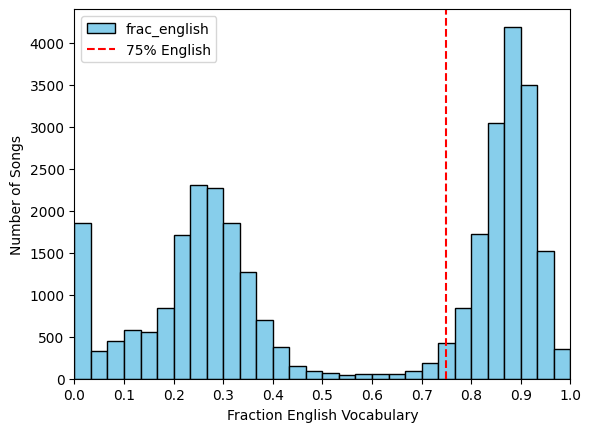

In [75]:
web2lowerset = get_english_words_set(['web2'], lower=True)
# compare intersection of vocab to the size of the vocab
df_filtered_lyrics['frac_english'] = [len(vocab.intersection(web2lowerset))/len(vocab) for vocab in df_filtered_lyrics['song_vocab'].to_list()]

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
df_filtered_lyrics['frac_english'].plot.hist(bins=30, edgecolor='black', color='skyblue',)
plt.xlabel("Fraction English Vocabulary")
plt.ylabel("Number of Songs")
plt.xticks(np.arange(0, 1.1, 0.1))
ax.set_xlim(0,1.0)
plt.axvline(0.75, color='red', linestyle='--', label=r'75% English')
plt.legend()
plt.show()

In [76]:
# keep songs that have over 75% english

df_english = df_filtered_lyrics[df_filtered_lyrics['frac_english'] >= 0.75]

df_english.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15434 entries, 699 to 41865
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   track_id        15434 non-null  object 
 1   track_genre     15434 non-null  object 
 2   id              15434 non-null  object 
 3   lyrics          15434 non-null  object 
 4   original_genre  15434 non-null  object 
 5   parent_genre    15434 non-null  object 
 6   included        15434 non-null  bool   
 7   notes           2509 non-null   object 
 8   lyric_count     15434 non-null  int64  
 9   song_vocab      15434 non-null  object 
 10  lyrics_cleaned  15434 non-null  object 
 11  frac_english    15434 non-null  float64
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 1.4+ MB


In [77]:
df_english['parent_genre'].value_counts()

parent_genre
Electronic          4411
Rock                2463
Metal               2261
Folk/Country        1608
Pop                 1424
World/Regional       857
Soul/Funk            784
Asian Pop            481
Reggae/Caribbean     431
Jazz & Blues         286
Classical            222
Hip-Hop & R&B        144
Latin                 62
Name: count, dtype: int64

In [81]:
# remove latin
df_master = df_english[df_english['parent_genre'] != 'latin'][['track_id','lyrics','lyrics_cleaned','track_genre','parent_genre']]

In [82]:
df_master.head()

,track_id,lyrics,lyrics_cleaned,track_genre,parent_genre
699,4pR4oQJULf7FDB54TleMyH,"Jireh, You are enough\n Jireh, You are enough\...",jireh you are enough\n jireh you are enough\n ...,afrobeat,World/Regional
736,7t6UycwC3vvVtTvbhdNSY9,I had a dream\n With the sound of your voice\n...,i had a dream\n with the sound of your voice\n...,afrobeat,World/Regional
756,4Z02tygBhQ3PZXKvwAl44s,Three months of winter coolness\n And awesome ...,three months of winter coolness\n and awesome ...,afrobeat,World/Regional
760,0FLmR0blAIztjE7YsQpoYc,"Shimmy shimmy ya, shimmy yam, shimmy yay\n Gim...",shimmy shimmy ya shimmy yam shimmy yay\n gimme...,afrobeat,World/Regional
778,49NyAaqgD1KExP3L9IgqT8,You know it's la plastilina mosh\n They break ...,you know its la plastilina mosh\n they break y...,afrobeat,World/Regional


In [83]:
df_master.to_csv('dataset.csv',index=False)